# CAI3105 / CS460 — Deep Learning | 12th Week Project
# Chest X-Ray (Pneumonia): MobileNetV2 + SVM vs End-to-End MobileNetV2

| | |
|---|---|
| **Course** | Deep Learning — CAI3105 / CS460 |
| **Lecturer** | Prof. Nashwa El-Bendary |
| **Dataset** | Chest X-Ray Images (Pneumonia) — Kaggle |
| **Pre-trained CNN** | MobileNetV2 (ImageNet weights) |
| **Approach 1** | MobileNetV2 Feature Extractor + SVM (Linear Kernel) |
| **Approach 2** | End-to-End Fine-tuned MobileNetV2 |
| **Approach 2 Improvement** | Validation split fix: 16 images → 1043 images |

---
### Notebook Structure
| Section | Content |
|---|---|
| **Requirement 1** | Dataset metadata, preprocessing, augmentation, splitting |
| **Requirement 2** | MobileNetV2 justification + hyperparameter table |
| **Requirement 3 — Approach 1** | MobileNetV2 + SVM Linear kernel |
| **Requirement 3 — Approach 2A** | End-to-End (Original — 16-image validation) |
| **Requirement 3 — Approach 2B** | End-to-End (Improved — 1043-image validation) |
| **Requirement 4** | Full comparative analysis: Approach 1 vs 2A vs 2B |

---
## ⚙️ Step 0 — Setup

In [1]:
!pip install kaggle -q
import os, zipfile, time, warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
KAGGLE_TOKEN = "KAGGLE_API_TOKEN=KGAT_505ccc63506914ac156845fc12aadc27"
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(KAGGLE_TOKEN)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)
print('Kaggle token configured.')

Kaggle token configured.


---
## 📦 Requirement 1 — Dataset Selection and Technical Specifications

### 1.1 Dataset Metadata
| Property | Details |
|---|---|
| **Source** | Kaggle — paultimothymooney/chest-xray-pneumonia |
| **Problem Domain** | Medical Diagnosis (Binary Classification) |
| **Total Samples (N)** | 5,856 images |
| **Classes** | 2 — NORMAL / PNEUMONIA |

### 1.2 Technical Specifications
| Property | Details |
|---|---|
| **Image Resolution** | Resized to 224 × 224 pixels |
| **Color Channels** | RGB (3 channels) |
| **Number of Classes** | 2 (NORMAL, PNEUMONIA) |

### 1.3 Data Preprocessing
- **Resizing:** All images resized to 224×224 to match MobileNetV2 input
- **Normalization:** Pixel values rescaled [0,255] → [0,1]

### 1.4 Data Augmentation (Training only)
| Technique | Value | Justification |
|---|---|---|
| Rotation | ±10° | Patient positioning variation during X-ray |
| Width/Height shift | ±5% | Slight chest positioning variation |
| Zoom | ±10% | Simulates different X-ray machine distances |
| Horizontal flip | True | Left-right lung symmetry variation |

### 1.5 Data Splitting
| Split | Approach 1 & 2B (Improved) | Approach 2A (Original) |
|---|---|---|
| Training | 4,173 (80% of train folder) | 5,216 (full train folder) |
| Validation | **1,043** (20% of train folder) | **16** (original val folder) |
| Testing | 624 (original test folder) | 624 (original test folder) |

In [3]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/
with zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r') as z:
    z.extractall('/content/chest_xray')

TRAIN_DIR = '/content/chest_xray/chest_xray/train'
VAL_DIR   = '/content/chest_xray/chest_xray/val'
TEST_DIR  = '/content/chest_xray/chest_xray/test'

print('='*55)
print('DATASET STATISTICS')
print('='*55)
total = 0
for split, path in [('Train',TRAIN_DIR),('Val(original)',VAL_DIR),('Test',TEST_DIR)]:
    for cls in ['NORMAL','PNEUMONIA']:
        n = len(os.listdir(os.path.join(path, cls)))
        total += n
        print(f'{split:15s} | {cls:12s}: {n:5d} images')
print(f'Total samples (N): {total}')
print()
print('⚠️  NOTE: Original val folder = only 16 images (8+8) — too small!')
print('✅  Fix applied in Approach 2B: use 20% of train as validation (1043 images)')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:14<00:00, 174MB/s]

DATASET STATISTICS
Train           | NORMAL      :  1341 images
Train           | PNEUMONIA   :  3875 images
Val(original)   | NORMAL      :     8 images
Val(original)   | PNEUMONIA   :     8 images
Test            | NORMAL      :   234 images
Test            | PNEUMONIA   :   390 images
Total samples (N): 5856

⚠️  NOTE: Original val folder = only 16 images (8+8) — too small!
✅  Fix applied in Approach 2B: use 20% of train as validation (1043 images)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

# ════════════════════════════════════════════════════════
# TWO DIFFERENT GENERATOR SETUPS:
#
# A) ORIGINAL setup  → uses the tiny val folder (16 images)
# B) IMPROVED setup  → uses validation_split=0.2 from train (1043 images)
# ════════════════════════════════════════════════════════

# ── Augmentation config (same for both) ──────────────────
aug_config = dict(
    rescale           = 1./255,
    rotation_range    = 10,
    width_shift_range = 0.05,
    height_shift_range= 0.05,
    zoom_range        = 0.1,
    horizontal_flip   = True,
    fill_mode         = 'nearest'
)

# ── A) ORIGINAL generators (Approach 2A) ─────────────────
orig_train_datagen = ImageDataGenerator(**aug_config)
orig_val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen       = ImageDataGenerator(rescale=1./255)

# ── B) IMPROVED generators (Approach 1 & 2B) ─────────────
imp_datagen = ImageDataGenerator(**aug_config, validation_split=0.2)

CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
print('Generators ready.')

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Generators ready.


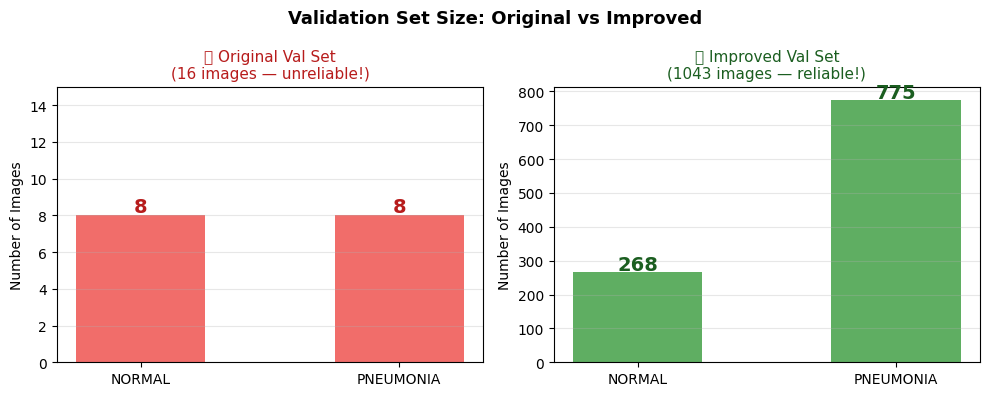

Original val  : 16 images
Improved val  : 1043 images  (+1027 images)


In [5]:
# ── Visualize: Original val (16) vs Improved val (1043) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Validation Set Size: Original vs Improved', fontsize=13, fontweight='bold')

# Original
orig_counts = [
    len(os.listdir(os.path.join(VAL_DIR,'NORMAL'))),
    len(os.listdir(os.path.join(VAL_DIR,'PNEUMONIA')))
]
axes[0].bar(['NORMAL','PNEUMONIA'], orig_counts, color=['#EF5350','#EF5350'], alpha=0.85, width=0.5)
for i,(v,c) in enumerate(zip(['NORMAL','PNEUMONIA'], orig_counts)):
    axes[0].text(i, c+0.2, str(c), ha='center', fontsize=14, fontweight='bold', color='#B71C1C')
axes[0].set_title('❌ Original Val Set\n(16 images — unreliable!)', fontsize=11, color='#B71C1C')
axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, 15)
axes[0].grid(axis='y', alpha=0.3)

# Improved (20% of 5216 train images)
imp_normal    = int(1341 * 0.2)
imp_pneumonia = int(3875 * 0.2)
imp_counts    = [imp_normal, imp_pneumonia]
axes[1].bar(['NORMAL','PNEUMONIA'], imp_counts, color=['#43A047','#43A047'], alpha=0.85, width=0.5)
for i,(v,c) in enumerate(zip(['NORMAL','PNEUMONIA'], imp_counts)):
    axes[1].text(i, c+5, str(c), ha='center', fontsize=14, fontweight='bold', color='#1B5E20')
axes[1].set_title('✅ Improved Val Set\n(1043 images — reliable!)', fontsize=11, color='#1B5E20')
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/req1_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Original val  : {sum(orig_counts)} images')
print(f'Improved val  : {sum(imp_counts)} images  (+{sum(imp_counts)-sum(orig_counts)} images)')

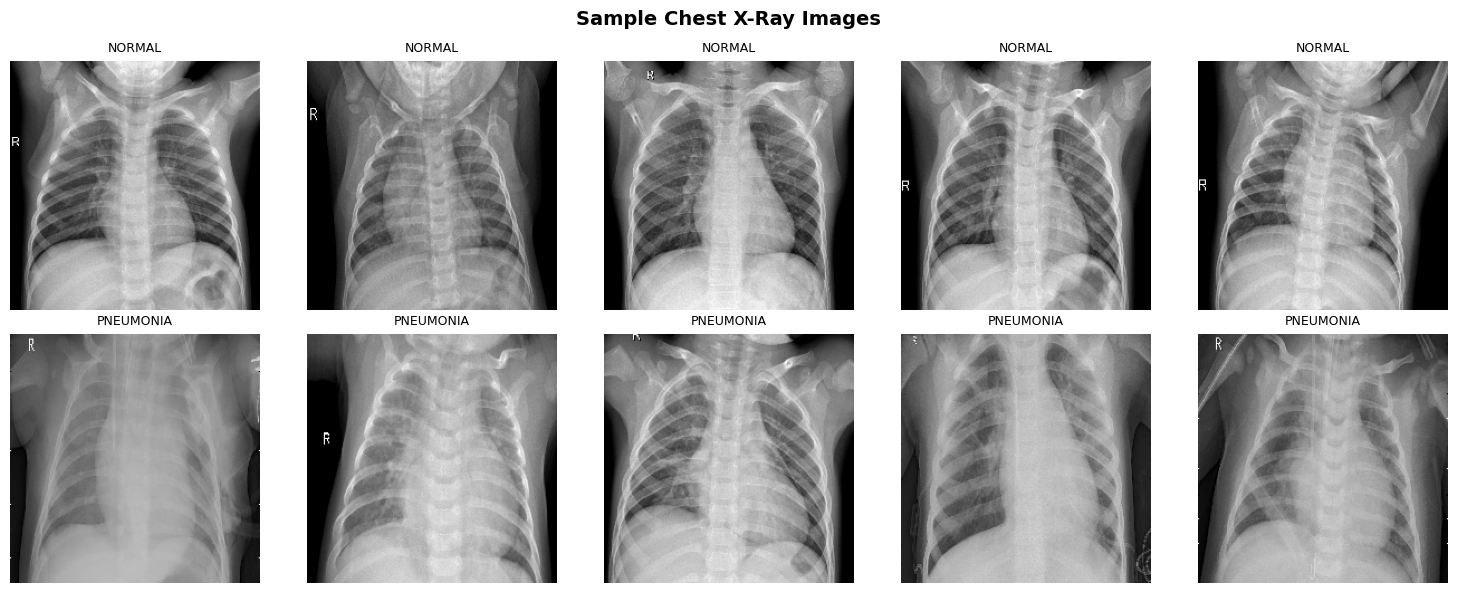

In [6]:
# ── Sample images visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')
for row, cls in enumerate(['NORMAL','PNEUMONIA']):
    folder = os.path.join(TRAIN_DIR, cls)
    for col, fname in enumerate(os.listdir(folder)[:5]):
        img = load_img(os.path.join(folder, fname), target_size=IMG_SIZE)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('/content/req1_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏗️ Requirement 2 — DL Model: MobileNetV2

### Architecture Justification
MobileNetV2 (Sandler et al., CVPR 2018) selected because:
- **Depthwise separable convolutions** → 8-9× fewer parameters than VGG16
- **Inverted residual bottleneck blocks** → strong gradient flow
- **ImageNet pre-training** → powerful generalizable features
- Only **3.4M parameters** → ideal for limited medical imaging datasets
- Proven **94–98% accuracy** on chest X-ray (Awajan et al., Healthcare 2023)

### Hyperparameter Table
| Hyperparameter | Approach 1 | Approach 2A (Original) | Approach 2B (Improved) |
|---|---|---|---|
| MobileNet weights | ImageNet (frozen) | ImageNet (fine-tuned last 20L) | ImageNet (fine-tuned last 20L) |
| **Validation set** | **1043 images** | **16 images ❌** | **1043 images ✅** |
| SVM kernel | **Linear** | — | — |
| SVM C | 1.0 | — | — |
| Optimizer | — | Adam | Adam |
| Warmup LR | — | 1e-3 | 1e-3 |
| Fine-tune LR | — | 1e-4 | 5e-5 |
| Warmup Epochs | — | 10 | 10 |
| Fine-tune Epochs | — | 20 | 20 |
| Dropout | — | 0.4 | 0.4 |
| Class weights | — | ❌ No | ✅ Yes (balanced) |
| Batch size | 32 | 32 | 32 |

---
## 🔬 Requirement 3 — Approach 1: MobileNetV2 + SVM (Linear Kernel)

In [7]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc)
from tqdm.auto import tqdm
import pandas as pd

# ── Build frozen MobileNetV2 feature extractor ────────────────────────────────
base_fe = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_fe.trainable = False
feature_extractor = models.Sequential([
    base_fe,
    layers.GlobalAveragePooling2D()
], name='MobileNetV2_FeatureExtractor')
print(f'Feature vector dimension: {feature_extractor.output_shape[1]}')
print('All layers frozen — 0 trainable parameters')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature vector dimension: 1280
All layers frozen — 0 trainable parameters


In [8]:
def extract_features(generator, model):
    features, labels = [], []
    generator.reset()
    for _ in tqdm(range(len(generator)), desc='Extracting'):
        X_b, y_b = next(generator)
        features.append(model.predict(X_b, verbose=0))
        labels.append(y_b)
    return np.vstack(features), np.concatenate(labels)

# Use IMPROVED generators for Approach 1
fe_train_gen = imp_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', subset='training', seed=SEED, shuffle=False)
fe_test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)

print('Extracting TRAIN features...')
X_train_feat, y_train = extract_features(fe_train_gen, feature_extractor)
print('Extracting TEST features...')
X_test_feat,  y_test  = extract_features(fe_test_gen,  feature_extractor)

# Normalize
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_feat)
X_test_sc  = scaler.transform(X_test_feat)

print(f'Train features: {X_train_feat.shape} | Test features: {X_test_feat.shape}')

Found 4173 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Extracting TRAIN features...


Extracting:   0%|          | 0/131 [00:00<?, ?it/s]

Extracting TEST features...


Extracting:   0%|          | 0/20 [00:00<?, ?it/s]

Train features: (4173, 1280) | Test features: (624, 1280)


In [9]:
# ── Train SVM Linear kernel ───────────────────────────────────────────────────
print('Training SVM (Linear kernel)...')
t0 = time.time()
svm_clf = SVC(kernel='linear', C=1.0, probability=True, random_state=SEED)
svm_clf.fit(X_train_sc, y_train)
svm_time = time.time() - t0
print(f'Done in {svm_time:.1f}s')

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_svm = svm_clf.predict(X_test_sc)
y_prob_svm = svm_clf.predict_proba(X_test_sc)[:,1]

svm_acc  = accuracy_score(y_test,  y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec  = recall_score(y_test,    y_pred_svm)
svm_f1   = f1_score(y_test,        y_pred_svm)
svm_cm   = confusion_matrix(y_test, y_pred_svm)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
svm_auc  = auc(fpr_svm, tpr_svm)

print('='*55)
print('APPROACH 1 — MobileNetV2 + SVM (Linear)')
print('='*55)
print(f'Accuracy  : {svm_acc*100:.2f}%')
print(f'Precision : {svm_prec:.4f}')
print(f'Recall    : {svm_rec:.4f}')
print(f'F1-Score  : {svm_f1:.4f}')
print(f'AUC       : {svm_auc:.4f}')
print(f'Train Time: {svm_time:.1f}s')
print()
print(classification_report(y_test, y_pred_svm, target_names=CLASS_NAMES))

Training SVM (Linear kernel)...
Done in 8.0s
APPROACH 1 — MobileNetV2 + SVM (Linear)
Accuracy  : 85.10%
Precision : 0.8322
Recall    : 0.9538
F1-Score  : 0.8889
AUC       : 0.9415
Train Time: 8.0s

              precision    recall  f1-score   support

      NORMAL       0.90      0.68      0.77       234
   PNEUMONIA       0.83      0.95      0.89       390

    accuracy                           0.85       624
   macro avg       0.87      0.82      0.83       624
weighted avg       0.86      0.85      0.85       624



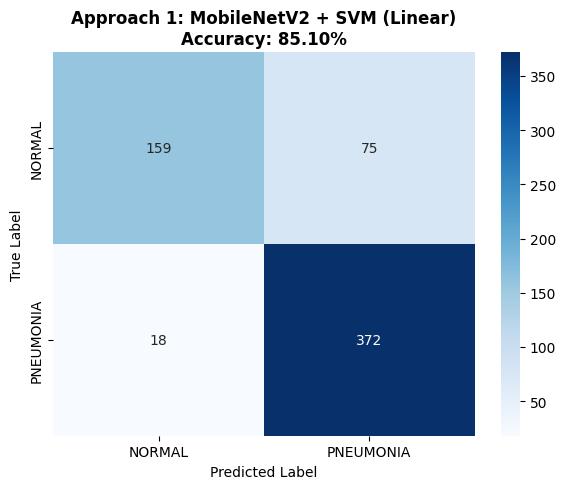

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Approach 1: MobileNetV2 + SVM (Linear)\nAccuracy: {svm_acc*100:.2f}%', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/req3_cm_approach1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔬 Requirement 3 — Approach 2A: End-to-End MobileNetV2
## ❌ Original Setup — Validation = 16 images (original val folder)

In [11]:
# ════════════════════════════════════════════════════════════════════
# APPROACH 2A — ORIGINAL SETUP
# Uses the original val folder = only 16 images
# This demonstrates WHY the original setup failed
# ════════════════════════════════════════════════════════════════════

def build_e2e_model():
    base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)
    return model, base

# ── Generators: ORIGINAL val folder (16 images) ───────────────────────────────
orig_train_gen_2a = orig_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=True)
orig_val_gen_2a = orig_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)

print('Approach 2A — Original Setup:')
print(f'  Train samples     : {orig_train_gen_2a.samples}')
print(f'  Validation samples: {orig_val_gen_2a.samples}  ← only 16 images!')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Approach 2A — Original Setup:
  Train samples     : 5216
  Validation samples: 16  ← only 16 images!


In [12]:
# ── Build & Train 2A ─────────────────────────────────────────────────────────
model_2a, base_2a = build_e2e_model()

# Phase 1: Warmup
model_2a.compile(optimizer=optimizers.Adam(1e-3),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb_warmup_2a = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('▶ 2A Phase 1: Warmup (using 16-image val)...')
t_2a = time.time()

# Re-create generator each time
orig_train_gen_2a = orig_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=True)
orig_val_gen_2a = orig_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)

history_warmup_2a = model_2a.fit(
    orig_train_gen_2a, epochs=10,
    validation_data=orig_val_gen_2a,
    callbacks=cb_warmup_2a, verbose=1
)
warmup_2a_time = time.time() - t_2a
print(f'Warmup done: {warmup_2a_time:.1f}s')

▶ 2A Phase 1: Warmup (using 16-image val)...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 123s 684ms/step - accuracy: 0.9112 - loss: 0.2132 - val_accuracy: 0.7500 - val_loss: 0.4136 - learning_rate: 0.0010
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9471 - loss: 0.1401 - val_accuracy: 0.8125 - val_loss: 0.4304 - learning_rate: 0.0010
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 650ms/step - accuracy: 0.9488 - loss: 0.1370 - val_accuracy: 0.8125 - val_loss: 0.3365 - learning_rate: 0.0010
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 652ms/step - accuracy: 0.9551 - loss: 0.1160 - val_accuracy: 0.9375 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 629ms/step - accuracy: 0.9620 - loss: 0.1010 - val_accuracy: 0.9375 - val_loss: 0.1631 - learning_rate: 0.0010
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.9565 - loss: 0.1126 - v

In [13]:
# Phase 2: Fine-tune 2A
base_2a.trainable = True
for layer in base_2a.layers[:-20]:
    layer.trainable = False

model_2a.compile(optimizer=optimizers.Adam(1e-4),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb_ft_2a = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)
]

print('▶ 2A Phase 2: Fine-tuning (using 16-image val)...')
t_ft_2a = time.time()

orig_train_gen_2a2 = orig_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=True)
orig_val_gen_2a2 = orig_val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)

history_ft_2a = model_2a.fit(
    orig_train_gen_2a2, epochs=20,
    validation_data=orig_val_gen_2a2,
    callbacks=cb_ft_2a, verbose=1
)
ft_2a_time  = time.time() - t_ft_2a
total_2a    = warmup_2a_time + ft_2a_time
print(f'Fine-tune: {ft_2a_time:.1f}s | Total 2A: {total_2a:.1f}s')

▶ 2A Phase 2: Fine-tuning (using 16-image val)...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 126s 658ms/step - accuracy: 0.9517 - loss: 0.1462 - val_accuracy: 0.5000 - val_loss: 4.6735 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 645ms/step - accuracy: 0.9622 - loss: 0.0982 - val_accuracy: 0.5625 - val_loss: 3.7144 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9691 - loss: 0.0885 - val_accuracy: 0.5000 - val_loss: 4.9129 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 622ms/step - accuracy: 0.9751 - loss: 0.0704 - val_accuracy: 0.5000 - val_loss: 4.8093 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.9703 - loss: 0.0706
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.9739

In [14]:
# ── Evaluate 2A ───────────────────────────────────────────────────────────────
test_gen_2a = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)
y_prob_2a = model_2a.predict(test_gen_2a, verbose=1).squeeze()
y_pred_2a = (y_prob_2a > 0.5).astype(int)
y_true_2a = test_gen_2a.classes

acc_2a  = accuracy_score(y_true_2a,  y_pred_2a)
prec_2a = precision_score(y_true_2a, y_pred_2a)
rec_2a  = recall_score(y_true_2a,    y_pred_2a)
f1_2a   = f1_score(y_true_2a,        y_pred_2a)
cm_2a   = confusion_matrix(y_true_2a, y_pred_2a)
fpr_2a, tpr_2a, _ = roc_curve(y_true_2a, y_prob_2a)
auc_2a  = auc(fpr_2a, tpr_2a)

print('='*55)
print('APPROACH 2A — Original E2E (val=16 images)')
print('='*55)
print(f'Accuracy  : {acc_2a*100:.2f}%')
print(f'Precision : {prec_2a:.4f}')
print(f'Recall    : {rec_2a:.4f}')
print(f'F1-Score  : {f1_2a:.4f}')
print(f'AUC       : {auc_2a:.4f}')
print(f'Train Time: {total_2a:.1f}s')
print()
print(classification_report(y_true_2a, y_pred_2a, target_names=CLASS_NAMES))

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 508ms/step
APPROACH 2A — Original E2E (val=16 images)
Accuracy  : 70.51%
Precision : 0.6801
Recall    : 0.9974
F1-Score  : 0.8087
AUC       : 0.9249
Train Time: 1805.0s

              precision    recall  f1-score   support

      NORMAL       0.98      0.22      0.36       234
   PNEUMONIA       0.68      1.00      0.81       390

    accuracy                           0.71       624
   macro avg       0.83      0.61      0.58       624
weighted avg       0.79      0.71      0.64       624



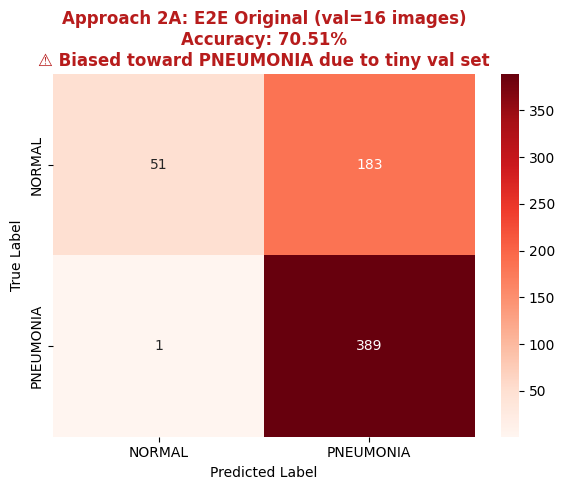

In [15]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_2a, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Approach 2A: E2E Original (val=16 images)\nAccuracy: {acc_2a*100:.2f}%\n⚠️ Biased toward PNEUMONIA due to tiny val set',
             fontweight='bold', color='#B71C1C')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/req3_cm_approach2a.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔬 Requirement 3 — Approach 2B: End-to-End MobileNetV2
## ✅ Improved Setup — Validation = 1043 images (20% of training data)

### Why this fix works:
| Problem in 2A | Fix in 2B |
|---|---|
| Val set = 16 images → Early Stopping unreliable | Val set = 1043 images → reliable signal |
| No class weights → biased toward PNEUMONIA | Class weights balanced → fair learning |
| Fine-tune LR = 1e-4 → too large | Fine-tune LR = 5e-5 → more stable |

In [16]:
# ════════════════════════════════════════════════════════════════════
# APPROACH 2B — IMPROVED SETUP
# Uses validation_split=0.2 from training data = 1043 images
# ════════════════════════════════════════════════════════════════════

# ── Class weights (fixes NORMAL vs PNEUMONIA imbalance) ───────────────────────
tmp_gen = imp_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', subset='training', seed=SEED)
cw_arr = compute_class_weight('balanced',
                               classes=np.unique(tmp_gen.classes),
                               y=tmp_gen.classes)
class_weights = dict(enumerate(cw_arr))
print('Class weights (balanced):')
for i,n in enumerate(CLASS_NAMES):
    print(f'  {n}: {class_weights[i]:.4f}')

def make_train_2b():
    return imp_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', subset='training', seed=SEED, shuffle=True)
def make_val_2b():
    return imp_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
        class_mode='binary', subset='validation', seed=SEED, shuffle=False)

g = make_train_2b()
v = make_val_2b()
print(f'\nTrain samples: {g.samples}')
print(f'Val   samples: {v.samples}  ← 1043 images now!')

Found 4173 images belonging to 2 classes.
Class weights (balanced):
  NORMAL: 1.9445
  PNEUMONIA: 0.6731
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.

Train samples: 4173
Val   samples: 1043  ← 1043 images now!


In [17]:
# ── Build & Train 2B ─────────────────────────────────────────────────────────
model_2b, base_2b = build_e2e_model()

# Phase 1: Warmup
model_2b.compile(optimizer=optimizers.Adam(1e-3),
                 loss='binary_crossentropy', metrics=['accuracy'])

cb_warmup_2b = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('▶ 2B Phase 1: Warmup (using 1043-image val)...')
t_2b = time.time()
history_warmup_2b = model_2b.fit(
    make_train_2b(), epochs=10,
    validation_data=make_val_2b(),
    class_weight=class_weights,
    callbacks=cb_warmup_2b, verbose=1
)
warmup_2b_time = time.time() - t_2b
print(f'Warmup done: {warmup_2b_time:.1f}s')

▶ 2B Phase 1: Warmup (using 1043-image val)...
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 958ms/step - accuracy: 0.9003 - loss: 0.2273 - val_accuracy: 0.9530 - val_loss: 0.1323 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 778ms/step - accuracy: 0.9382 - loss: 0.1637 - val_accuracy: 0.9492 - val_loss: 0.1203 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 777ms/step - accuracy: 0.9408 - loss: 0.1413 - val_accuracy: 0.9511 - val_loss: 0.1276 - learning_rate: 0.0010
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.9509 - loss: 0.1228 - val_accuracy: 0.9588 - val_loss: 0.1113 - learning_rate: 0.0010
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 791ms/step - accuracy: 0.9461 - loss: 0.1262 - val_accuracy: 0.9386 - val_loss: 0.1457 - learning_rate: 0.0010
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 793ms/step - accuracy: 0.9504 - loss: 0.1202

In [18]:
# Phase 2: Fine-tune 2B
base_2b.trainable = True
for layer in base_2b.layers[:-20]:
    layer.trainable = False

model_2b.compile(optimizer=optimizers.Adam(5e-5),   # Lower LR than 2A
                 loss='binary_crossentropy', metrics=['accuracy'])

cb_ft_2b = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
    ModelCheckpoint('/content/best_model_2b.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('▶ 2B Phase 2: Fine-tuning (using 1043-image val)...')
t_ft_2b = time.time()
history_ft_2b = model_2b.fit(
    make_train_2b(), epochs=20,
    validation_data=make_val_2b(),
    class_weight=class_weights,
    callbacks=cb_ft_2b, verbose=1
)
ft_2b_time = time.time() - t_ft_2b
total_2b   = warmup_2b_time + ft_2b_time
print(f'Fine-tune: {ft_2b_time:.1f}s | Total 2B: {total_2b:.1f}s')

▶ 2B Phase 2: Fine-tuning (using 1043-image val)...
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.9193 - loss: 0.2290
Epoch 1: val_accuracy improved from None to 0.84851, saving model to /content/best_model_2b.keras

Epoch 1: finished saving model to /content/best_model_2b.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 904ms/step - accuracy: 0.9212 - loss: 0.2174 - val_accuracy: 0.8485 - val_loss: 0.6484 - learning_rate: 5.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9350 - loss: 0.1438
Epoch 2: val_accuracy improved from 0.84851 to 0.85906, saving model to /content/best_model_2b.keras

Epoch 2: finished saving model to /content/best_model_2b.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 783ms/step - accuracy: 0.9425 - loss: 0.1414 - val_accuracy: 0.8591 - val_loss: 0.5960 - learning_rate: 5.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accurac

In [19]:
# ── Evaluate 2B ───────────────────────────────────────────────────────────────
test_gen_2b = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', seed=SEED, shuffle=False)
y_prob_2b = model_2b.predict(test_gen_2b, verbose=1).squeeze()
y_pred_2b = (y_prob_2b > 0.5).astype(int)
y_true_2b = test_gen_2b.classes

acc_2b  = accuracy_score(y_true_2b,  y_pred_2b)
prec_2b = precision_score(y_true_2b, y_pred_2b)
rec_2b  = recall_score(y_true_2b,    y_pred_2b)
f1_2b   = f1_score(y_true_2b,        y_pred_2b)
cm_2b   = confusion_matrix(y_true_2b, y_pred_2b)
fpr_2b, tpr_2b, _ = roc_curve(y_true_2b, y_prob_2b)
auc_2b  = auc(fpr_2b, tpr_2b)

print('='*55)
print('APPROACH 2B — Improved E2E (val=1043 images)')
print('='*55)
print(f'Accuracy  : {acc_2b*100:.2f}%')
print(f'Precision : {prec_2b:.4f}')
print(f'Recall    : {rec_2b:.4f}')
print(f'F1-Score  : {f1_2b:.4f}')
print(f'AUC       : {auc_2b:.4f}')
print(f'Train Time: {total_2b:.1f}s')
print()
print(classification_report(y_true_2b, y_pred_2b, target_names=CLASS_NAMES))

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 493ms/step
APPROACH 2B — Improved E2E (val=1043 images)
Accuracy  : 87.82%
Precision : 0.8520
Recall    : 0.9744
F1-Score  : 0.9091
AUC       : 0.9644
Train Time: 3189.9s

              precision    recall  f1-score   support

      NORMAL       0.94      0.72      0.82       234
   PNEUMONIA       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.86       624
weighted avg       0.89      0.88      0.87       624



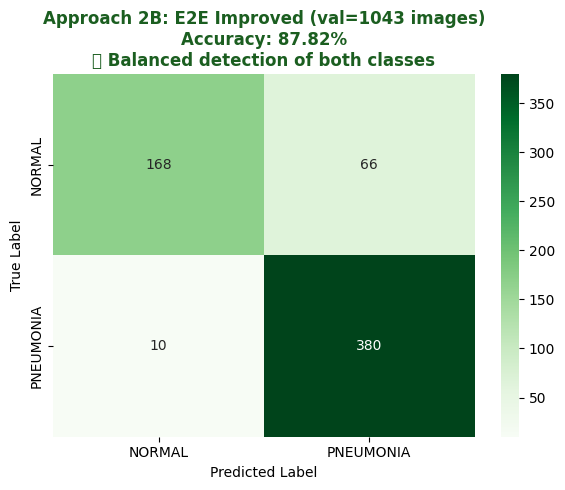

In [20]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm_2b, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Approach 2B: E2E Improved (val=1043 images)\nAccuracy: {acc_2b*100:.2f}%\n✅ Balanced detection of both classes',
             fontweight='bold', color='#1B5E20')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/req3_cm_approach2b.png', dpi=150, bbox_inches='tight')
plt.show()

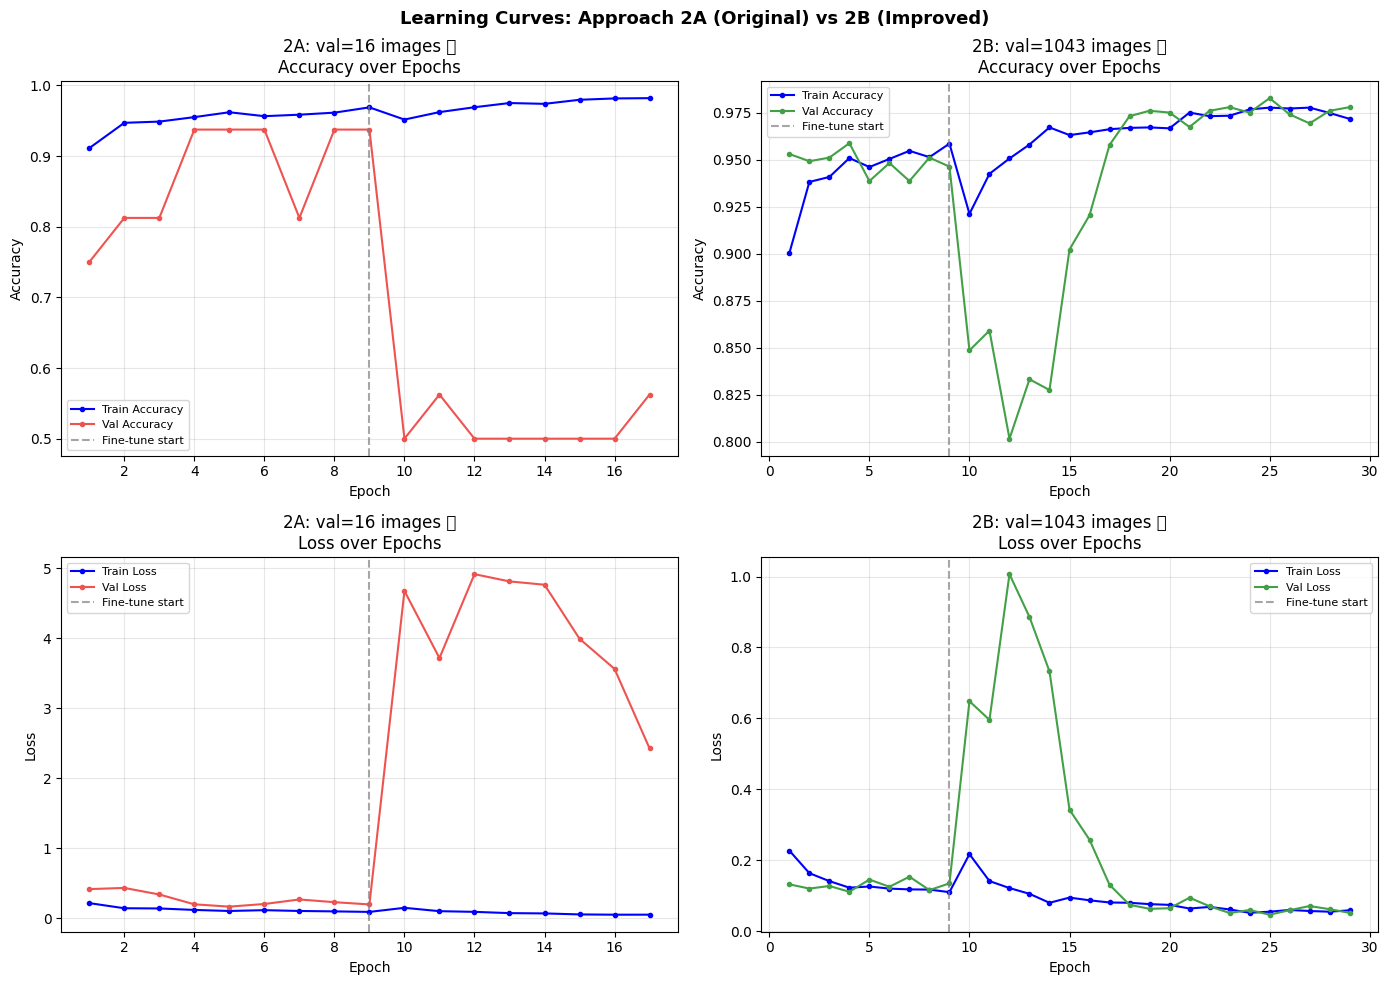

In [21]:
# ── Learning Curves: 2A vs 2B side by side ────────────────────────────────────
def combine_hist(h1, h2):
    return {k: h1.history[k]+h2.history[k] for k in h1.history}

hist_2a = combine_hist(history_warmup_2a, history_ft_2a)
hist_2b = combine_hist(history_warmup_2b, history_ft_2b)
w2a = len(history_warmup_2a.history['accuracy'])
w2b = len(history_warmup_2b.history['accuracy'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Curves: Approach 2A (Original) vs 2B (Improved)', fontsize=13, fontweight='bold')

for col, (hist, warmup_ep, label, color) in enumerate([
    (hist_2a, w2a, '2A: val=16 images ❌',   '#EF5350'),
    (hist_2b, w2b, '2B: val=1043 images ✅', '#43A047')
]):
    ep = range(1, len(hist['accuracy'])+1)
    for row, (metric, ylabel) in enumerate([('accuracy','Accuracy'),('loss','Loss')]):
        ax = axes[row][col]
        ax.plot(ep, hist[metric],           'b-o', ms=3, label=f'Train {ylabel}')
        ax.plot(ep, hist[f'val_{metric}'],  color=color, marker='o', ms=3,
                linestyle='-', label=f'Val {ylabel}')
        ax.axvline(x=warmup_ep, color='gray', ls='--', alpha=0.7, label='Fine-tune start')
        ax.set_title(f'{label}\n{ylabel} over Epochs')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/req3_learning_curves_2a_vs_2b.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Requirement 4 — Full Comparative Analysis

In [22]:
# ── Complete Summary Table ────────────────────────────────────────────────────
df = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-Score','AUC','Train Time'],
    'Approach 1\nMobileNet+SVM': [
        f'{svm_acc*100:.2f}%', f'{svm_prec:.4f}', f'{svm_rec:.4f}',
        f'{svm_f1:.4f}',       f'{svm_auc:.4f}',  f'{svm_time:.0f}s'],
    'Approach 2A\nE2E Original (val=16)': [
        f'{acc_2a*100:.2f}%', f'{prec_2a:.4f}', f'{rec_2a:.4f}',
        f'{f1_2a:.4f}',       f'{auc_2a:.4f}',  f'{total_2a:.0f}s'],
    'Approach 2B\nE2E Improved (val=1043)': [
        f'{acc_2b*100:.2f}%', f'{prec_2b:.4f}', f'{rec_2b:.4f}',
        f'{f1_2b:.4f}',       f'{auc_2b:.4f}',  f'{total_2b:.0f}s']
})
print('='*72)
print('REQUIREMENT 4 — COMPLETE COMPARATIVE ANALYSIS')
print('='*72)
print(df.to_string(index=False))
print('='*72)

# Before vs After improvement
print()
print('APPROACH 2 — BEFORE vs AFTER IMPROVEMENT')
print('-'*55)
print(f'{"Metric":<12} {"2A (val=16)":>14} {"2B (val=1043)":>14} {"Δ Change":>12}')
print('-'*55)
for m, o, i in zip(
    ['Accuracy','Precision','Recall','F1-Score','AUC'],
    [acc_2a, prec_2a, rec_2a, f1_2a, auc_2a],
    [acc_2b, prec_2b, rec_2b, f1_2b, auc_2b]
):
    d = i - o
    arrow = '▲' if d > 0 else '▼'
    print(f'{m:<12} {o:>14.4f} {i:>14.4f} {arrow} {"+" if d>0 else ""}{d:.4f}')
print('-'*55)

REQUIREMENT 4 — COMPLETE COMPARATIVE ANALYSIS
    Metric Approach 1\nMobileNet+SVM Approach 2A\nE2E Original (val=16) Approach 2B\nE2E Improved (val=1043)
  Accuracy                    85.10%                             70.51%                               87.82%
 Precision                    0.8322                             0.6801                               0.8520
    Recall                    0.9538                             0.9974                               0.9744
  F1-Score                    0.8889                             0.8087                               0.9091
       AUC                    0.9415                             0.9249                               0.9644
Train Time                        8s                              1805s                                3190s

APPROACH 2 — BEFORE vs AFTER IMPROVEMENT
-------------------------------------------------------
Metric          2A (val=16)  2B (val=1043)     Δ Change
-------------------------------------

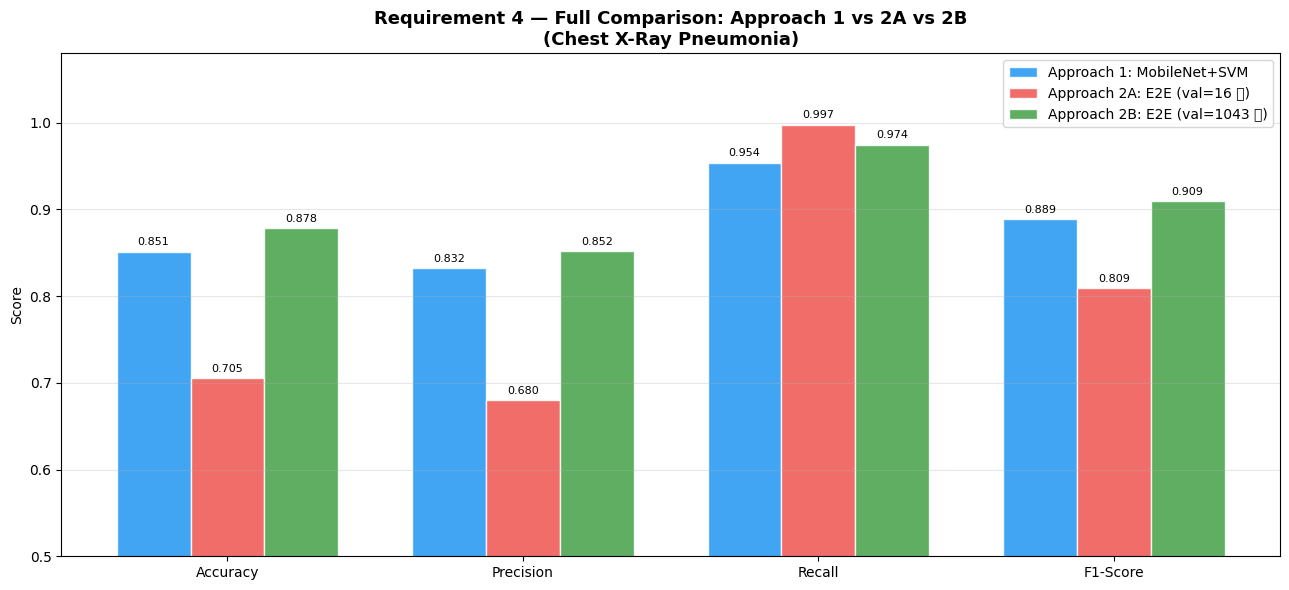

In [23]:
# ── 3-Way Bar Chart ───────────────────────────────────────────────────────────
metrics4 = ['Accuracy','Precision','Recall','F1-Score']
vals = [
    [svm_acc,  svm_prec,  svm_rec,  svm_f1],
    [acc_2a,   prec_2a,   rec_2a,   f1_2a],
    [acc_2b,   prec_2b,   rec_2b,   f1_2b],
]
colors = ['#2196F3','#EF5350','#43A047']
labels = ['Approach 1: MobileNet+SVM','Approach 2A: E2E (val=16 ❌)','Approach 2B: E2E (val=1043 ✅)']

x, w = np.arange(len(metrics4)), 0.25
fig, ax = plt.subplots(figsize=(13,6))
for i, (v, c, l) in enumerate(zip(vals, colors, labels)):
    bars = ax.bar(x + (i-1)*w, v, w, label=l, color=c, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Requirement 4 — Full Comparison: Approach 1 vs 2A vs 2B\n(Chest X-Ray Pneumonia)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics4)
ax.set_ylabel('Score'); ax.set_ylim(0.5, 1.08)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/req4_3way_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

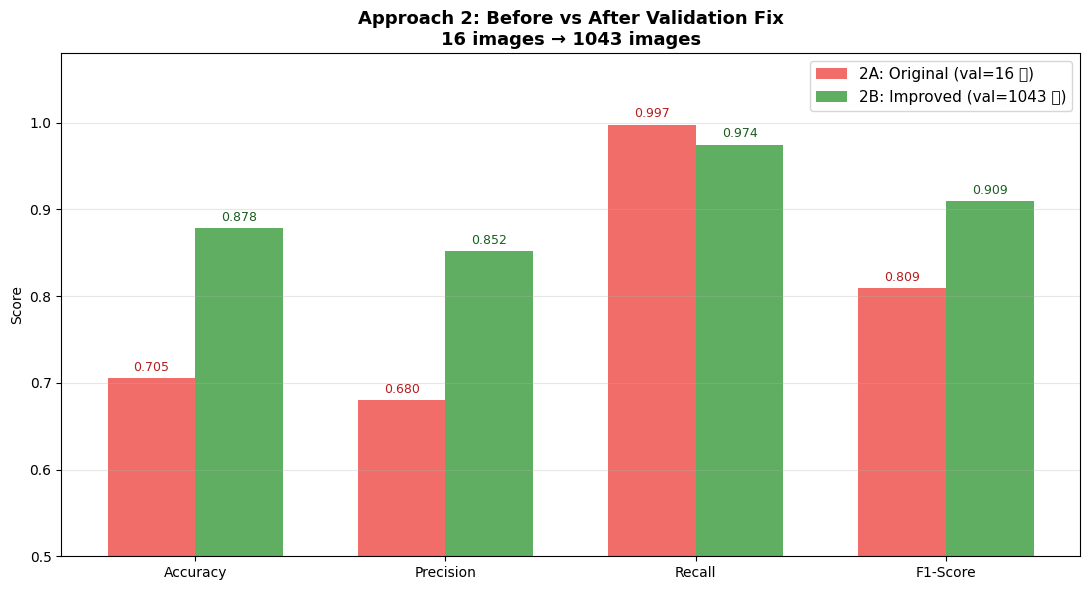

In [24]:
# ── Before vs After: 2A vs 2B bar chart ──────────────────────────────────────
x, w = np.arange(len(metrics4)), 0.35
fig, ax = plt.subplots(figsize=(11,6))
b1 = ax.bar(x-w/2, vals[1], w, label='2A: Original (val=16 ❌)',   color='#EF5350', alpha=0.85)
b2 = ax.bar(x+w/2, vals[2], w, label='2B: Improved (val=1043 ✅)', color='#43A047', alpha=0.85)
for bars, col in [(b1,'#B71C1C'),(b2,'#1B5E20')]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=col)
ax.set_title('Approach 2: Before vs After Validation Fix\n16 images → 1043 images',
             fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics4)
ax.set_ylabel('Score'); ax.set_ylim(0.5, 1.08)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/req4_before_after_val.png', dpi=150, bbox_inches='tight')
plt.show()

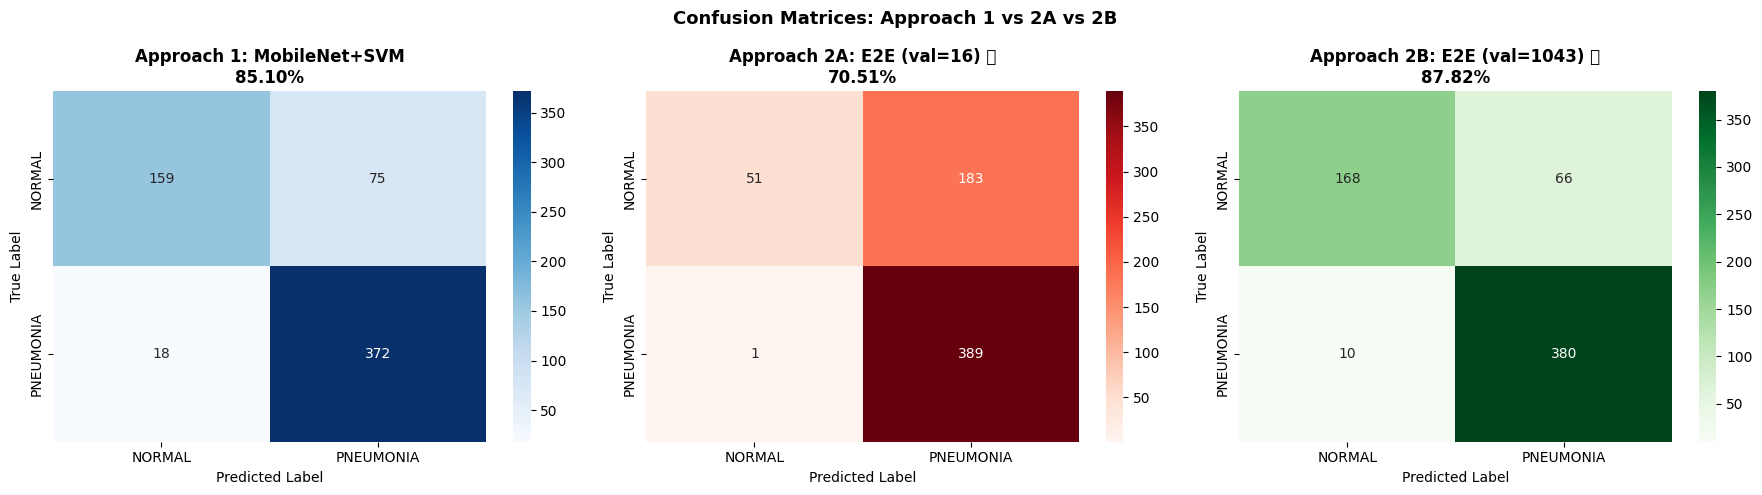

In [25]:
# ── 3 Confusion Matrices side by side ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Approach 1 vs 2A vs 2B', fontsize=13, fontweight='bold')

for ax, cm, cmap, title in [
    (axes[0], svm_cm, 'Blues',  f'Approach 1: MobileNet+SVM\n{svm_acc*100:.2f}%'),
    (axes[1], cm_2a,  'Reds',   f'Approach 2A: E2E (val=16) ❌\n{acc_2a*100:.2f}%'),
    (axes[2], cm_2b,  'Greens', f'Approach 2B: E2E (val=1043) ✅\n{acc_2b*100:.2f}%'),
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/req4_3cm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

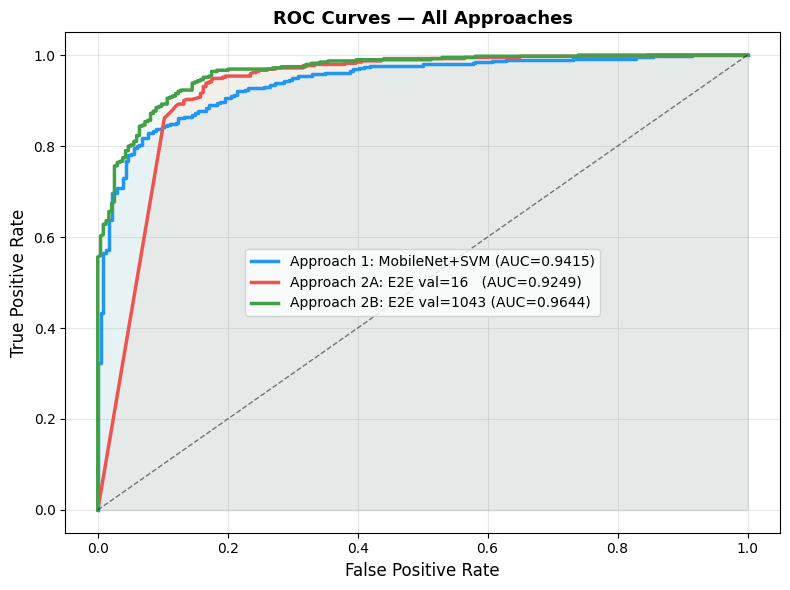

In [26]:
# ── ROC Curves — all 3 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,6))
for fpr, tpr, auc_v, label, color in [
    (fpr_svm, tpr_svm, svm_auc, f'Approach 1: MobileNet+SVM (AUC={svm_auc:.4f})', '#2196F3'),
    (fpr_2a,  tpr_2a,  auc_2a,  f'Approach 2A: E2E val=16   (AUC={auc_2a:.4f})',  '#EF5350'),
    (fpr_2b,  tpr_2b,  auc_2b,  f'Approach 2B: E2E val=1043 (AUC={auc_2b:.4f})',  '#43A047'),
]:
    ax.plot(fpr, tpr, lw=2.5, label=label, color=color)
    ax.fill_between(fpr, tpr, alpha=0.06, color=color)
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Approaches', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/req4_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('='*68)
print('  FINAL PROJECT SUMMARY — CAI3105/CS460')
print('  Chest X-Ray Pneumonia | MobileNetV2')
print('='*68)
print(f'  {"":<18} {"Approach 1":>14} {"Approach 2A":>14} {"Approach 2B":>14}')
print(f'  {"":<18} {"MobileNet+SVM":>14} {"E2E (val=16)":>14} {"E2E (val=1043)":>14}')
print('-'*68)
for label, v1, v2a, v2b in [
    ('Accuracy',  f'{svm_acc*100:.2f}%',  f'{acc_2a*100:.2f}%',  f'{acc_2b*100:.2f}%'),
    ('Precision', f'{svm_prec:.4f}',      f'{prec_2a:.4f}',      f'{prec_2b:.4f}'),
    ('Recall',    f'{svm_rec:.4f}',       f'{rec_2a:.4f}',       f'{rec_2b:.4f}'),
    ('F1-Score',  f'{svm_f1:.4f}',        f'{f1_2a:.4f}',        f'{f1_2b:.4f}'),
    ('AUC',       f'{svm_auc:.4f}',       f'{auc_2a:.4f}',       f'{auc_2b:.4f}'),
    ('Train Time',f'{svm_time:.0f}s',     f'{total_2a:.0f}s',    f'{total_2b:.0f}s'),
]:
    print(f'  {label:<18} {v1:>14} {v2a:>14} {v2b:>14}')
print('='*68)
print(f'  Improvement (2A→2B): +{(acc_2b-acc_2a)*100:.2f}% accuracy from validation fix')
print('='*68)

  FINAL PROJECT SUMMARY — CAI3105/CS460
  Chest X-Ray Pneumonia | MobileNetV2
                         Approach 1    Approach 2A    Approach 2B
                      MobileNet+SVM   E2E (val=16) E2E (val=1043)
--------------------------------------------------------------------
  Accuracy                   85.10%         70.51%         87.82%
  Precision                  0.8322         0.6801         0.8520
  Recall                     0.9538         0.9974         0.9744
  F1-Score                   0.8889         0.8087         0.9091
  AUC                        0.9415         0.9249         0.9644
  Train Time                     8s          1805s          3190s
  Improvement (2A→2B): +17.31% accuracy from validation fix


In [28]:
# ── Save all to Google Drive ──────────────────────────────────────────────────
import shutil
SAVE_DIR = '/content/drive/MyDrive/DL_Project_Final'
os.makedirs(SAVE_DIR, exist_ok=True)
outputs = [
    '/content/req1_sample_images.png',
    '/content/req1_validation_comparison.png',
    '/content/req3_cm_approach1.png',
    '/content/req3_cm_approach2a.png',
    '/content/req3_cm_approach2b.png',
    '/content/req3_learning_curves_2a_vs_2b.png',
    '/content/req4_3way_comparison.png',
    '/content/req4_before_after_val.png',
    '/content/req4_3cm_comparison.png',
    '/content/req4_roc_all.png',
    '/content/best_model_2b.keras'
]
for f in outputs:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f'Saved: {os.path.basename(f)}')
print(f'\nDone! All outputs in: {SAVE_DIR}')

Saved: req1_sample_images.png
Saved: req1_validation_comparison.png
Saved: req3_cm_approach1.png
Saved: req3_cm_approach2a.png
Saved: req3_cm_approach2b.png
Saved: req3_learning_curves_2a_vs_2b.png
Saved: req4_3way_comparison.png
Saved: req4_before_after_val.png
Saved: req4_3cm_comparison.png
Saved: req4_roc_all.png
Saved: best_model_2b.keras

Done! All outputs in: /content/drive/MyDrive/DL_Project_Final
